# 눈썹 재생성 파이프라인 (Colab)

**전체 흐름**

```
원본 이미지
 └─ [STEP 1] MediaPipe 랜드마크 → 눈썹 마스크 생성 (눈 보호 영역 제외) + 눈썹 중심 512 크롭
 └─ [STEP 2] LaMa 인페인팅으로 마스크 영역의 원본 눈썹 제거   (이진 마스크 사용)
 └─ [STEP 3] SD Inpaint + LoRA 로 새 눈썹 생성                (경계를 흐린 feather 마스크 사용)
```

- 마스크는 **두 번** 쓰인다. 지울 때는 딱딱한(이진) 마스크, 생성할 때는 경계를
  GaussianBlur 로 흐린 그라데이션 마스크를 써서 피부와 자연스럽게 이어지게 한다.
- BiSeNet(face-parsing) 관련 코드는 현재 파이프라인에서 사용하지 않으므로
  맨 아래 **부록** 섹션으로 옮김.


## 1. 패키지 설치

**주의:** 이 셀을 실행한 뒤 반드시 아래 '런타임 재시작' 셀까지 실행하세요.
`mediapipe` / `opencv-python-headless`가 Colab 기본 numpy와 다른 버전을 설치하면서
`ValueError: numpy.dtype size changed` 오류가 나기 때문입니다 (numpy 재설치 후 재시작 필요).

In [1]:
%%capture
!pip install -q diffusers transformers peft accelerate simple-lama-inpainting mediapipe opencv-python-headless safetensors
!pip install -q -U "torchao>=0.16.0"
# torch / torchvision은 Colab 기본 환경에 이미 설치되어 있습니다 (CUDA 지원 버전).
# 버전 충돌이 나면 아래 주석을 해제해서 재설치하세요.
# !pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121

런타임 재시작 셀 (세션이 다운되어도 정상 동작이니 당황하지 말고 다음 셀 실행)

In [ ]:
import os
os.kill(os.getpid(), 9)

## 2. Google Drive 마운트 & 경로 설정

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# TODO: 실제 프로젝트 폴더 경로로 수정하세요
ROOT_PATH = "/content/drive/MyDrive/eyebrows"

assert os.path.isdir(ROOT_PATH), f"경로를 찾을 수 없습니다: {ROOT_PATH}"
print("ROOT_PATH:", ROOT_PATH)
print(os.listdir(ROOT_PATH))

ROOT_PATH: /content/drive/MyDrive/eyebrows
['backbone.ipynb', 'util', 'masking_bisenet', 'lora_checkpoint', 'data', '명확한 방향성이 필요하다.gdoc', 'output_img', 'pipeline', 'test.jpg', 'eyebrow_pipeline_colab (1).ipynb']


## 3. Import & 초기 설정

In [3]:
import os
import sys
import datetime

import cv2
import numpy as np
import torch
from PIL import Image
from google.colab.patches import cv2_imshow

sys.path.insert(0, ROOT_PATH)

# Colab CUDA 환경: onnxruntime-gpu 충돌 방지용 (SD는 PyTorch만 사용)
try:
    import diffusers.utils.import_utils as _diffusers_import_utils
    _diffusers_import_utils._onnx_available = False
except ImportError:
    pass

from diffusers import StableDiffusionInpaintPipeline, UniPCMultistepScheduler, UNet2DConditionModel, AutoencoderKL
from transformers import CLIPTextModel
from simple_lama_inpainting import SimpleLama
from peft import PeftModel
import transformers
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 구버전 diffusers 호환 (CLIPFeatureExtractor 이름 변경 대응)
if not hasattr(transformers, 'CLIPFeatureExtractor'):
    transformers.CLIPFeatureExtractor = transformers.CLIPImageProcessor

Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## 4. MediaPipe FaceLandmarker

478개 얼굴 랜드마크 중 눈썹/눈에 해당하는 정점 인덱스를 사용한다.
- 눈썹 인덱스: 마스크(인페인팅 대상) 영역
- 눈 인덱스: 마스크가 눈을 침범하지 않도록 보호(가드) 영역

In [11]:
MODEL_PATH = os.path.join(ROOT_PATH, "data", "face_landmarker.task")

if not os.path.exists(MODEL_PATH):
    print("Downloading face_landmarker.task...")
    import urllib.request
    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        MODEL_PATH,
    )
    print("face_landmarker.task download complete.")

_detector = None

def _get_detector():
    """FaceLandmarker 를 전역 캐싱해서 반환 (매번 생성하면 모델 로딩 비용이 크다)."""
    global _detector
    if _detector is None:
        options = vision.FaceLandmarkerOptions(
            base_options=python.BaseOptions(
                model_asset_path=MODEL_PATH,
                delegate=python.BaseOptions.Delegate.CPU,
            ),
            num_faces=1,
        )
        _detector = vision.FaceLandmarker.create_from_options(options)
    return _detector

# 눈썹 영역 정점 (마스크 대상)
LEFT_BROW  = [156, 70, 63, 105, 66, 107, 9, 221,  222, 223, 224, 225, 113, 124]
RIGHT_BROW = [383, 300, 293, 334, 296, 336,  9, 441, 442, 443, 444, 445, 342, 353]

# 눈 영역 정점 (마스크에서 제외할 보호 영역)
LEFT_EYE   = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
RIGHT_EYE  = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]

## 5. 마스크 유틸리티

- `get_landmarks` — 이미지에서 478개 랜드마크의 픽셀 좌표 추출
- `dilate_mask` — 마스크 팽창 (랜드마크 다각형이 실제 눈썹보다 작게 잡히는 문제 보정)
- `get_brow_mask` — 눈썹 마스크 생성 (팽창 → 눈 가드 차감)

In [5]:
def get_landmarks(image_bgr):
    """MediaPipe FaceLandmarker로 얼굴 랜드마크 478개의 픽셀 좌표를 추출한다.

    MediaPipe는 이미지 크기와 무관한 정규화 좌표(0.0~1.0)를 반환하므로,
    원본 이미지 해상도에 맞는 실제 픽셀 좌표로 변환해서 돌려준다.

    Args:
        image_bgr: (H, W, 3) uint8, OpenCV 기본 BGR 순서

    Returns:
        (478, 2) int32 배열. 각 행이 [x, y] 픽셀 좌표.
        얼굴을 찾지 못하면 None.
    """
    h, w = image_bgr.shape[:2]

    # MediaPipe는 RGB를 요구하지만 OpenCV는 BGR로 읽는다.
    mp_img = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB),
    )
    res = _get_detector().detect(mp_img)

    # 얼굴 미검출(측면/가림/저화질) 시 빈 리스트가 온다
    if not res.face_landmarks:
        return None

    lm = res.face_landmarks[0]          # num_faces=1 이므로 첫 얼굴만
    return np.array([[p.x * w, p.y * h] for p in lm], dtype=np.int32)


def dilate_mask(mask, pixels=5):
    """마스크의 흰색 영역을 사방으로 `pixels`만큼 부풀린다 (팽창 / dilation).

    랜드마크 다각형은 곡선을 직선으로 근사하고 잔털을 포함하지 못하므로
    실제 눈썹보다 작게 잡힌다. 그대로 인페인팅하면 마스크 밖에 남은
    원본 눈썹이 테두리처럼 남는다.

    Args:
        mask   : (H, W) uint8. 0=배경, 255=대상 영역
        pixels : 확장할 반경(px). 실제 커널 크기는 (2*pixels+1)

    Returns:
        (H, W) uint8. 입력과 같은 크기, 흰 영역만 커진 마스크
    """
    # 커널은 홀수 크기여야 중심 픽셀이 존재해 사방으로 균등하게 팽창한다.
    k = 2 * pixels + 1
    # 사각형 커널은 대각선 방향으로 더 퍼져 눈썹 꼬리가 각지게 뭉툭해지므로
    # 모든 방향으로 균등하게 퍼지는 타원 커널을 쓴다.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.dilate(mask, kernel, iterations=1)


def get_brow_mask(image_bgr, dilate_px=5, eye_guard_px=10, pts=None):
    """눈썹 영역만 흰색(255)인 인페인팅용 마스크 생성.

    Args:
        image_bgr    : (H, W, 3) uint8 원본 이미지
        dilate_px    : 눈썹 영역을 부풀릴 반경(px)
        eye_guard_px : 눈 보호 영역을 부풀릴 반경(px).
                       눈 랜드마크는 안구 노출 부위만 덮으므로,
                       눈꺼풀·쌍꺼풀까지 지키려면 이만큼 넓혀야 한다.
        pts          : 미리 계산한 랜드마크 (없으면 내부에서 추출)

    Returns:
        (H, W) uint8 마스크. 얼굴 미검출 시 None.
    """
    if pts is None:
        pts = get_landmarks(image_bgr)
    if pts is None:
        return None

    # 1) 눈썹 다각형 채우기
    mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [pts[LEFT_BROW], pts[RIGHT_BROW]], 255)

    # 2) 눈썹 팽창 (랜드마크 다각형이 실제 눈썹보다 작으므로)
    if dilate_px > 0:
        mask = dilate_mask(mask, dilate_px)

    # 3) 눈 가드를 별도 마스크로 만들어 팽창
    #    (눈썹 마스크에 직접 0을 칠하면 팽창시킬 수 없으므로 따로 만든다)
    eye_guard = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    cv2.fillPoly(eye_guard, [pts[LEFT_EYE], pts[RIGHT_EYE]], 255)
    if eye_guard_px > 0:
        eye_guard = dilate_mask(eye_guard, eye_guard_px)

    # 4) 눈썹 마스크에서 가드 영역을 차감
    mask[eye_guard > 0] = 0
    return mask

## 6. 시각화 헬퍼

In [7]:
def show(img, title="", scale=1.0):
    """BGR ndarray 또는 단채널 마스크를 Colab에 출력."""
    if title:
        print(f"--- {title} ---")
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if scale != 1.0:
        img = cv2.resize(img, None, fx=scale, fy=scale,
                         interpolation=cv2.INTER_NEAREST)
    cv2_imshow(img)


def overlay(img_bgr, mask, color=(255, 100, 100), alpha=0.45):
    """마스크를 원본 위에 반투명으로 얹어 확인."""
    m = (mask.astype(np.float32) / 255.0 * alpha)[..., None]
    layer = np.zeros_like(img_bgr); layer[:] = color
    return (img_bgr * (1 - m) + layer * m).astype(np.uint8)


def blend(fg, bg, mask_u8, ksize=None):
    """mask=255인 곳은 fg, 0인 곳은 bg. 경계는 블러로 부드럽게."""
    m = mask_u8.astype(np.float32) / 255.0
    if ksize:
        m = cv2.GaussianBlur(m, (ksize, ksize), 0)
    if m.ndim == 2:
        m = m[:, :, None]
    return (fg * m + bg * (1 - m)).astype(np.uint8)

### 마스크 생성 확인 (선택 실행)

In [12]:
img = cv2.imread(os.path.join(ROOT_PATH, "test.jpg"))
mask = get_brow_mask(img, dilate_px=23, eye_guard_px=23)
assert mask is not None, "얼굴 검출 실패"

show(mask, "마스크")
show(overlay(img, mask, color=(0, 0, 255)), "마스크 오버레이")

Output hidden; open in https://colab.research.google.com to view.

## 7. 모델 로딩 (SD + LoRA + LaMa)

- 베이스 모델: `emilianJR/epiCRealism` (SD1.5 계열 실사)
- LoRA: `ROOT_PATH/lora_checkpoint/` 아래 학습된 체크포인트 (unet + text_encoder)
- LaMa: 눈썹 제거용 인페인팅 모델

In [13]:
def resolve_lora_checkpoint_path():
    """lora_checkpoint 폴더에서 사용 가능한 체크포인트를 우선순위대로 탐색."""
    candidates = [
        "celeb_eyebrows_all_gender_integrated",
        "celeb_eyebrows_all_pro_v4",
    ]
    for name in candidates:
        path = os.path.join(ROOT_PATH, "lora_checkpoint", name)
        unet_weights = os.path.join(path, "unet", "adapter_model.safetensors")
        if os.path.isfile(unet_weights):
            return path, name
    raise FileNotFoundError(
        "LoRA checkpoint not found. Expected one of "
        + ", ".join(candidates)
        + f" under {os.path.join(ROOT_PATH, 'lora_checkpoint')}"
    )


def load_models():
    """SD Inpaint 파이프라인(+LoRA)과 LaMa를 로드한다."""
    base_model_path = "emilianJR/epiCRealism"
    lora_path, lora_name = resolve_lora_checkpoint_path()

    if torch.cuda.is_available():
        device, dtype = "cuda", torch.float16
    elif torch.backends.mps.is_available():
        device, dtype = "mps", torch.float32
    else:
        device, dtype = "cpu", torch.float32

    print(f"Loading base pipeline and LoRA checkpoint ({lora_name}) on {device}...")

    text_encoder = CLIPTextModel.from_pretrained(base_model_path, subfolder="text_encoder", torch_dtype=dtype)
    vae = AutoencoderKL.from_pretrained(base_model_path, subfolder="vae", torch_dtype=dtype)
    unet = UNet2DConditionModel.from_pretrained(base_model_path, subfolder="unet", torch_dtype=dtype)

    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        base_model_path, text_encoder=text_encoder, vae=vae, unet=unet,
        torch_dtype=dtype, low_cpu_mem_usage=True, safety_checker=None,
    )

    adapter_name = "unified_celeb"
    pipe.unet = PeftModel.from_pretrained(pipe.unet, os.path.join(lora_path, "unet"), adapter_name=adapter_name)
    pipe.text_encoder = PeftModel.from_pretrained(pipe.text_encoder, os.path.join(lora_path, "text_encoder"), adapter_name=adapter_name)
    print(f"Loaded LoRA checkpoint: {lora_name}")

    pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
    if device != "cuda":
        pipe.to(device)
        pipe.enable_attention_slicing()
        pipe.enable_vae_slicing()
    else:
        pipe.enable_model_cpu_offload()

    print("Loading LaMa inpainting model...")
    lama = SimpleLama()
    return pipe, lama, device

### 모델 로드 (한 번만 실행)

In [14]:
pipe, lama, device = load_models()
print("device:", device)

Loading base pipeline and LoRA checkpoint (celeb_eyebrows_all_gender_integrated) on cuda...


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

text_encoder/model.safetensors: reconstructing file:   0%|          |  0.00B /  492MB            

text_encoder/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Loaded LoRA checkpoint: celeb_eyebrows_all_gender_integrated
Loading LaMa inpainting model...


Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:00<00:00, 228MB/s]


device: cuda


## STEP 1 — 크롭 & 마스크 준비

원본 해상도 그대로 SD에 넣을 수 없으므로, 눈썹 주변을 정사각형으로 잘라
512x512로 리사이즈해서 작업한다. 랜드마크는 한 번만 추출해
마스크 생성과 크롭 계산에 공용으로 쓴다.

In [15]:
def get_brow_crop_from_pts(pts, image_shape, padding_ratio=1.3, min_size=512):
    """랜드마크 좌표에서 눈썹을 중심으로 한 정사각형 크롭 영역 계산.

    Returns:
        (x1, y1, w, h) — 이미지 경계 안으로 클램프된 정사각형
    """
    h, w = image_shape[:2]
    brow_pts = pts[LEFT_BROW + RIGHT_BROW]
    min_x, min_y = brow_pts.min(axis=0)
    max_x, max_y = brow_pts.max(axis=0)

    bw = max_x - min_x + 1
    bh = max_y - min_y + 1
    side = int(max(max(bw, bh) * padding_ratio, min_size))
    side = min(side, w, h)          # 이미지보다 클 수는 없음

    cx, cy = (min_x + max_x) // 2, (min_y + max_y) // 2
    x1 = int(np.clip(cx - side // 2, 0, w - side))
    y1 = int(np.clip(cy - side // 2, 0, h - side))
    return (x1, y1, side, side)


def apply_crop(image, crop_info, target_size=512, is_mask=False):
    """크롭 후 target_size 정사각형으로 리사이즈.

    is_mask=True면 AREA(축소)/LINEAR(확대)를 써서 알파값 오염을 막는다.
    LANCZOS는 링잉(overshoot) 때문에 마스크에는 금지.
    """
    x, y, cw, ch = crop_info
    cropped = image[y:y+ch, x:x+cw]

    if cw == target_size and ch == target_size:
        return cropped

    if is_mask:
        interp = cv2.INTER_AREA if cw > target_size else cv2.INTER_LINEAR
    else:
        interp = cv2.INTER_AREA if cw > target_size else cv2.INTER_LANCZOS4
    return cv2.resize(cropped, (target_size, target_size), interpolation=interp)


def step1_prepare(image_path, dilate_px=15, eye_guard_px=23,
                  padding_ratio=1.3, target_size=512):
    """이미지 로드 → 랜드마크 추출 → 마스크 생성 → 512 크롭.

    Returns (dict):
        original      : 원본 BGR (짧은 변 < target_size면 업스케일된 버전)
        landmarks     : (478, 2) 랜드마크 픽셀 좌표
        base_mask     : 원본 해상도 눈썹 마스크 (MediaPipe)
        crop_info     : (x, y, w, h) 크롭 영역
        image_512     : 크롭+리사이즈된 작업 이미지
        mask_512_base : 크롭+리사이즈된 마스크 (폴백용)
    """
    original_bgr = cv2.imread(image_path)
    if original_bgr is None:
        raise FileNotFoundError(image_path)

    # 짧은 변이 target_size보다 작으면 정사각형 크롭이 불가능 → 미리 업스케일
    h, w = original_bgr.shape[:2]
    if min(h, w) < target_size:
        s = target_size / min(h, w)
        original_bgr = cv2.resize(original_bgr, (int(round(w*s)), int(round(h*s))),
                                  interpolation=cv2.INTER_LANCZOS4)

    # 랜드마크는 한 번만 뽑아서 마스크와 크롭에 공용
    pts = get_landmarks(original_bgr)
    if pts is None:
        raise ValueError(f"얼굴 검출 실패: {image_path}")

    base_mask = get_brow_mask(original_bgr, dilate_px=dilate_px,
                              eye_guard_px=eye_guard_px, pts=pts)
    crop_info = get_brow_crop_from_pts(pts, original_bgr.shape,
                                       padding_ratio=padding_ratio,
                                       min_size=target_size)
    return {
        "original": original_bgr,
        "landmarks": pts,
        "base_mask": base_mask,
        "crop_info": crop_info,
        "image_512": apply_crop(original_bgr, crop_info, target_size),
        "mask_512_base": apply_crop(base_mask, crop_info, target_size, is_mask=True),
    }

In [16]:
S = step1_prepare(os.path.join(ROOT_PATH, "test.jpg"))

show(overlay(S["original"], S["base_mask"]), "눈썹 마스크 (원본 해상도)", 0.5)
show(overlay(S["image_512"], S["mask_512_base"]), "크롭 512 + 마스크")
print("crop_info:", S["crop_info"])

Output hidden; open in https://colab.research.google.com to view.

## STEP 2 — LaMa로 눈썹 지우기

크롭된 512 이미지에서 랜드마크를 **다시** 추출해 지우기용 마스크를 만든다.
(원본 해상도에서 만든 마스크를 리사이즈하면 dilate 반경이 크롭 배율에 따라
달라지므로, 512 기준으로 새로 만드는 편이 픽셀 단위 제어가 정확하다.)

LaMa 를 여러 번(passes) 반복 적용하면 남은 눈썹 흔적이 점점 줄어든다.

In [17]:
def step2_erase(S, lama, passes=3, dilate_px=23):
    """LaMa 인페인팅으로 눈썹 제거.

    Args:
        passes    : LaMa 반복 적용 횟수 (잔상 제거용)
        dilate_px : 512 크롭 기준 마스크 팽창 반경
    """
    erase_mask = get_brow_mask(S["image_512"], dilate_px=dilate_px)

    # 크롭 이미지에서 얼굴 재검출에 실패하면 STEP 1 마스크로 폴백
    if erase_mask is None or erase_mask.sum() == 0:
        print("[warn] 512 크롭에서 얼굴 검출 실패 → STEP 1 마스크로 폴백")
        erase_mask = S["mask_512_base"]

    pil = Image.fromarray(cv2.cvtColor(S["image_512"], cv2.COLOR_BGR2RGB))
    mask_pil = Image.fromarray(erase_mask).convert("L")

    stages = []
    for _ in range(passes):
        pil = lama(pil, mask_pil)
        stages.append(cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR))

    S["erase_mask_512"] = erase_mask
    S["erased_512"] = stages[-1]
    S["erase_stages"] = stages          # 반복 횟수 튜닝용
    return S

--- LaMa 지우기 마스크 ---


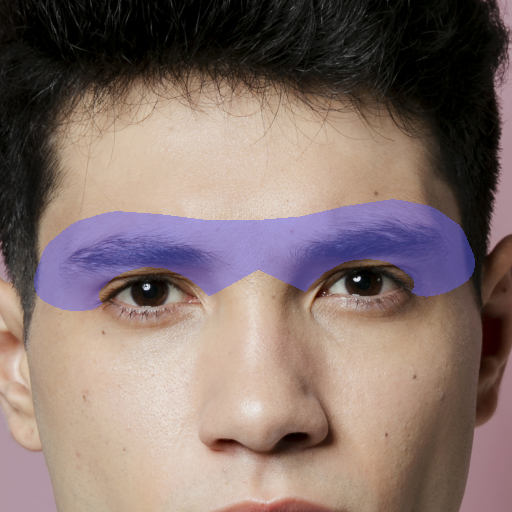

--- LaMa pass 1 ---


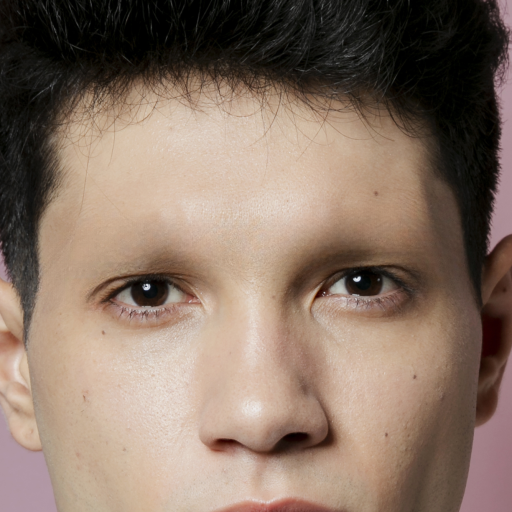

--- LaMa pass 2 ---


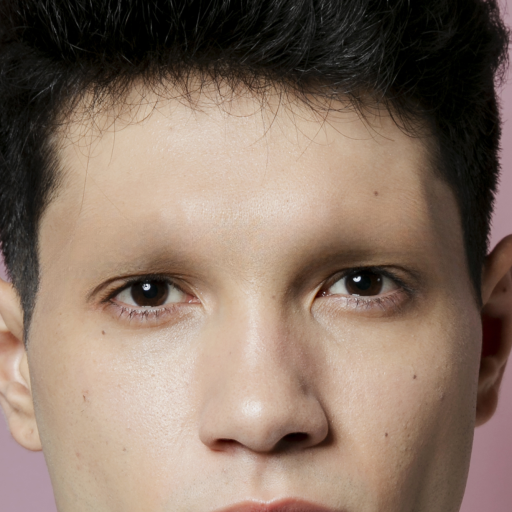

--- LaMa pass 3 ---


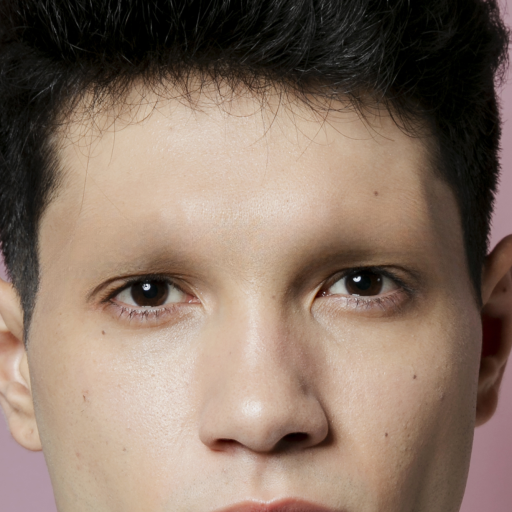

In [18]:
S = step2_erase(S, lama, passes=3, dilate_px=23)

show(overlay(S["image_512"], S["erase_mask_512"]), "LaMa 지우기 마스크")
for i, st in enumerate(S["erase_stages"], 1):
    show(st, f"LaMa pass {i}")

## STEP 3 — SD Inpaint + LoRA로 눈썹 생성

지우기와 달리 생성 마스크는 경계를 GaussianBlur 로 흐려서(feather)
새 눈썹과 피부가 자연스럽게 이어지게 한다.

In [19]:
PROMPT_T = (
    "a photo of {celeb} style eyebrows on a face, "
    "highly detailed, realistic skin texture, natural skin pores, "
    "soft even diffused lighting"
)

NEG = (
    "low quality, blurry, distorted, deformed, artifacts, "
    "cartoon, 3d render, painting, plastic skin, smooth skin, poreless, "
    "extra eyes, third eye, "
    "hard edges, seam, mismatched skin tone"
)


def make_gen_mask(S, feather=25, dilate_px=0):
    """생성용 그라데이션 마스크. 중심은 255, 경계로 갈수록 0."""
    m = S["erase_mask_512"].copy()          # LaMa에 쓴 것과 동일 영역
    if dilate_px > 0:
        m = dilate_mask(m, dilate_px)
    if feather > 0:
        k = feather * 2 + 1                 # 홀수 보장
        m = cv2.GaussianBlur(m, (k, k), 0)
    return m


def step3_generate(S, pipe, celeb, device,
                   seed=42, steps=40, guidance=7.0, strength=0.85,
                   lora_scale=1.15, feather=25, mask_mode="feathered"):
    """SD Inpaint + LoRA 로 새 눈썹 생성.

    mask_mode:
      "feathered" — 눈썹 영역 그라데이션 (권장)
      "binary"    — 눈썹 영역 이진
      "white"     — 전체 흰색 (img2img 에 가까운 원본 방식)
    """
    if mask_mode == "white":
        gen_mask = np.full((512, 512), 255, np.uint8)
    elif mask_mode == "binary":
        gen_mask = S["erase_mask_512"]
    else:
        gen_mask = make_gen_mask(S, feather=feather)

    S["gen_mask_512"] = gen_mask
    print(f"마스크: {mask_mode}, 최대값 {gen_mask.max()}, "
          f"픽셀 {np.count_nonzero(gen_mask)}")

    out = pipe(
        prompt=PROMPT_T.format(celeb=celeb),
        negative_prompt=NEG,
        image=Image.fromarray(cv2.cvtColor(S["erased_512"], cv2.COLOR_BGR2RGB)),
        mask_image=Image.fromarray(gen_mask).convert("L"),
        num_inference_steps=steps,
        guidance_scale=guidance,
        strength=strength,
        generator=torch.Generator(device).manual_seed(seed),
        cross_attention_kwargs={"scale": lora_scale},
    ).images[0]

    S["generated_512"] = cv2.cvtColor(np.array(out), cv2.COLOR_RGB2BGR)
    S["seed"] = seed

    # 필요 시 부록의 color_transfer 로 피부톤 보정:
    # S["corrected_512"] = color_transfer(S["generated_512"], S["erased_512"], S["mask_512_base"])
    return S

마스크: feathered, 최대값 255, 픽셀 53290


  0%|          | 0/28 [00:00<?, ?it/s]

--- 생성 마스크 ---


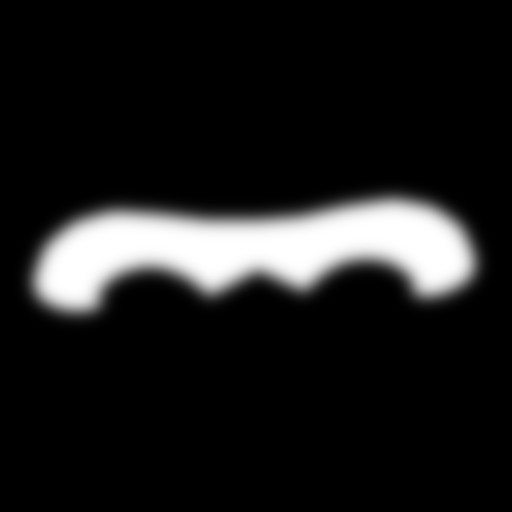

--- LaMa | 생성 | 원본 ---


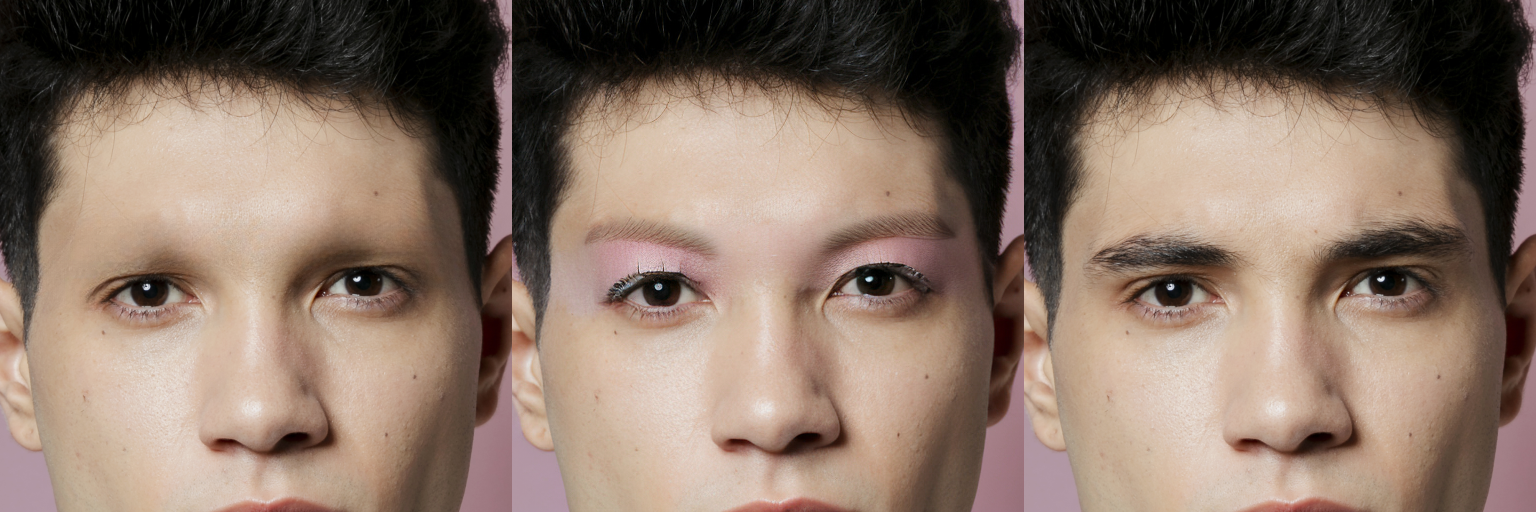

In [20]:
S = step3_generate(S, pipe, "고윤정", device, seed=42,
                   strength=0.7, feather=25, mask_mode="feathered")

show(S["gen_mask_512"], "생성 마스크")
show(np.hstack([S["erased_512"], S["generated_512"], S["image_512"]]),
     "LaMa | 생성 | 원본")

---
# 부록 — 현재 파이프라인에서 사용하지 않는 코드

메인 파이프라인은 MediaPipe 마스크만 사용한다. 아래는 나중에 쓸 수 있어
보관해 둔 코드들이며, **실행하지 않아도 파이프라인은 동작한다.**

## A. BiSeNet (face-parsing) 설치 & 가중치

세그멘테이션 기반 눈썹 마스크 실험용. ONNX 런타임과 resnet18 가중치가 필요하다.

In [ ]:
!pip install onnxruntime

In [ ]:
# 가중치 다운로드 (Colab 로컬)
!curl -L -o /content/resnet18.onnx https://github.com/yakhyo/face-parsing/releases/download/weights/resnet18.onnx

In [ ]:
# 드라이브에 이미 받아둔 가중치 확인
p = os.path.join(ROOT_PATH, "masking_bisenet/face-parsing/weights/resnet18.onnx")
print("존재:", os.path.exists(p))
if os.path.exists(p):
    print("크기(MB):", os.path.getsize(p) / 1024 / 1024)

## B. BiSeNet 기반 step1_prepare (미완성 — 실행 금지)

드라이브의 `masking_bisenet` / `util` 모듈에 의존하는 버전.
BiSeNet 세그멘테이션 마스크로 STEP 1을 대체하려던 실험 코드이며,
의존 함수(`generate_bisenet_face_parts_mask`, `get_zoom_crop_info` 등)의
주석을 해제해야 동작한다.

In [ ]:
# from masking_bisenet.generate_mask_bisenet import generate_bisenet_face_parts_mask
# from util.crop_face import get_zoom_crop_info, apply_crop, restore_crop

def step1_prepare_bisenet(image_path, dilate_px=15, padding_ratio=1.3):
    """BiSeNet 마스크 버전 STEP 1 (미완성)."""
    original_bgr = cv2.imread(image_path)
    if original_bgr is None:
        raise FileNotFoundError(image_path)

    # base_mask = generate_bisenet_face_parts_mask(original_bgr, parts=["eyebrows"])
    # base_mask = dilate_mask(base_mask, pixels=dilate_px)
    # crop_info = get_zoom_crop_info(base_mask, original_bgr.shape,
    #                                padding_ratio=padding_ratio, min_size=512)
    # return {
    #     "original": original_bgr,
    #     "base_mask": base_mask,
    #     "crop_info": crop_info,
    #     "image_512": apply_crop(original_bgr, crop_info, 512),
    #     "mask_512_base": apply_crop(base_mask, crop_info, 512, is_mask=True),
    # }
    raise NotImplementedError("BiSeNet 마스크 함수 연결 후 사용")

## C. 기타 미사용 유틸

- `_to_mediapipe_srgb` / `get_landmarks_new` — `get_landmarks` 와 중복 (정규화 좌표를 그대로 반환하는 버전)
- `get_canny_guide` — ControlNet 실험용 Canny 엣지 가이드
- `color_transfer` — 생성 결과의 피부톤을 원본 배경 통계에 맞추는 LAB 색 보정

In [ ]:
def _to_mediapipe_srgb(image_np: np.ndarray) -> np.ndarray:
    """MediaPipe Image() requires contiguous uint8 RGB (OpenCV paths pass BGR)."""
    if image_np.dtype != np.uint8:
        image_np = np.clip(image_np, 0, 255).astype(np.uint8)
    if image_np.ndim == 3 and image_np.shape[2] == 3:
        image_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
    return np.ascontiguousarray(image_np)


def get_landmarks_new(image_np):
    """정규화 좌표 객체를 그대로 반환하는 버전 (get_landmarks 와 중복)."""
    rgb = _to_mediapipe_srgb(image_np)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = _get_detector().detect(mp_image)
    if not result.face_landmarks:
        return None
    return result.face_landmarks[0]


def get_canny_guide(image_np):
    """ControlNet 실험용 Canny 엣지 가이드 이미지."""
    img = cv2.Canny(image_np, 100, 200)
    img = img[:, :, None]
    img = np.concatenate([img, img, img], axis=2)
    return Image.fromarray(img)

In [ ]:
def color_transfer(src, ref, mask):
    """mask=0(배경) 영역의 LAB 통계를 기준으로 src 색을 ref 에 맞춘다.

    생성 결과(src)의 피부톤이 LaMa 결과(ref)와 미묘하게 다를 때 보정용.
    """
    bg_mask = (mask == 0)
    if not np.any(bg_mask):
        return src
    src_lab = cv2.cvtColor(src, cv2.COLOR_BGR2LAB).astype(np.float32)
    ref_lab = cv2.cvtColor(ref, cv2.COLOR_BGR2LAB).astype(np.float32)
    for i in range(3):
        src_channel = src_lab[:, :, i]
        ref_channel = ref_lab[:, :, i]
        mean_src, std_src = src_channel[bg_mask].mean(), src_channel[bg_mask].std()
        mean_ref, std_ref = ref_channel[bg_mask].mean(), ref_channel[bg_mask].std()
        if std_src > 1e-5:
            src_lab[:, :, i] = (src_channel - mean_src) * (std_ref / std_src) + mean_ref
        else:
            src_lab[:, :, i] = src_channel - mean_src + mean_ref
    return cv2.cvtColor(np.clip(src_lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2BGR)